In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
iris = load_iris()
x = iris.data
y = iris.target

# Split into train/test sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

# Feature scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Train the KNN model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

# Make predictions
y_pred = knn.predict(x_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", (acc*100))


Accuracy: 93.33333333333333


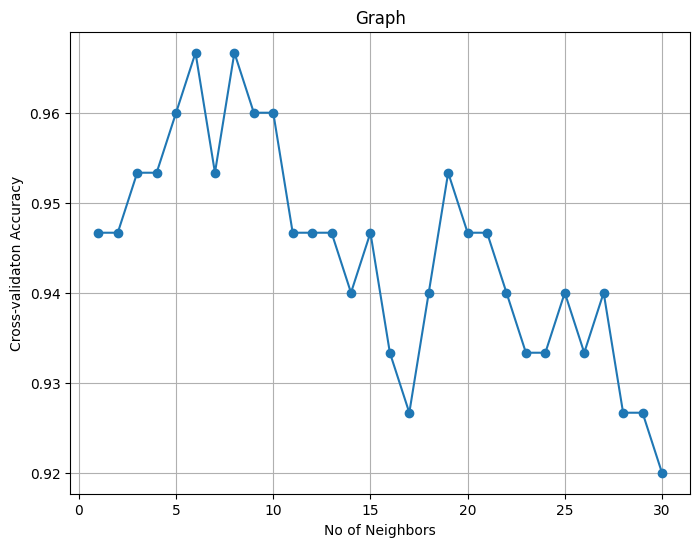

In [43]:
k_values = [i for i in range(1,31)]
scores = []
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn,x_scaled,y,cv=5)
    scores.append(np.mean(score))

plt.figure(figsize=(8,6))
plt.plot(k_values,scores,marker='o')
plt.title('Graph')
plt.xlabel('No of Neighbors')
plt.ylabel('Cross-validaton Accuracy')
plt.grid('True')
plt.show()

In [48]:
best_index = np.argmax(scores)
best_k = k_values[best_index]
print("Best k index : ",best_index)
print("Best k values : ",best_k)
print(f"Best k value accuracy : {scores[best_index]*100:.2f} %")

Best k index :  5
Best k values :  6
Best k value accuracy : 96.67 %


In [51]:
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

print(f"Accuracy score : {accuracy_score(y_test,y_pred)*100:.2f} %")

Accuracy score : 93.33 %


In [52]:
print("Correct Predictions:\n")
for i in range(len(y_test)):
    if y_test[i]==y_pred[i]:
        print(f"Index {i} : Predicted - {y_pred[i]}, Actual - {y_test[i]}")

print("\nWrong Predictions:\n")
for i in range(len(y_test)):
    if y_test[i]!=y_pred[i]:
        print(f"Index {i} : Predicted - {y_pred[i]}, Actual - {y_test[i]}")

Correct Predictions:

Index 0 : Predicted - 0, Actual - 0
Index 1 : Predicted - 2, Actual - 2
Index 2 : Predicted - 1, Actual - 1
Index 3 : Predicted - 1, Actual - 1
Index 4 : Predicted - 0, Actual - 0
Index 5 : Predicted - 1, Actual - 1
Index 6 : Predicted - 0, Actual - 0
Index 7 : Predicted - 0, Actual - 0
Index 8 : Predicted - 2, Actual - 2
Index 9 : Predicted - 1, Actual - 1
Index 10 : Predicted - 2, Actual - 2
Index 11 : Predicted - 2, Actual - 2
Index 12 : Predicted - 2, Actual - 2
Index 13 : Predicted - 1, Actual - 1
Index 14 : Predicted - 0, Actual - 0
Index 15 : Predicted - 0, Actual - 0
Index 16 : Predicted - 0, Actual - 0
Index 17 : Predicted - 1, Actual - 1
Index 18 : Predicted - 1, Actual - 1
Index 20 : Predicted - 0, Actual - 0
Index 21 : Predicted - 2, Actual - 2
Index 22 : Predicted - 1, Actual - 1
Index 24 : Predicted - 2, Actual - 2
Index 25 : Predicted - 1, Actual - 1
Index 26 : Predicted - 1, Actual - 1
Index 27 : Predicted - 0, Actual - 0
Index 28 : Predicted - 2, 

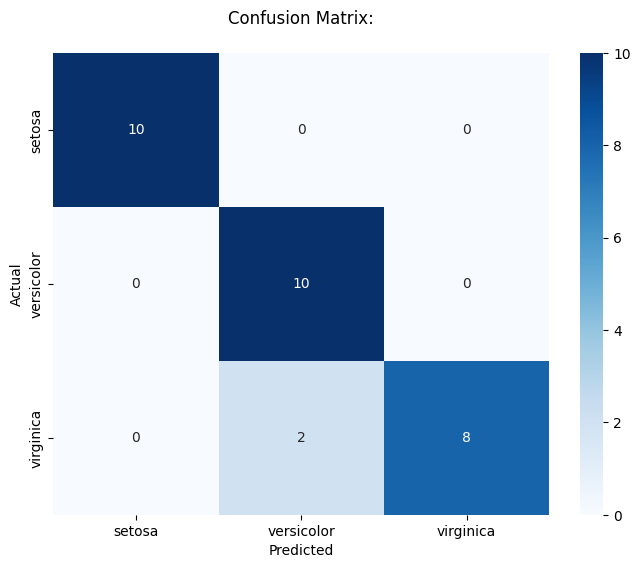

In [54]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(8,6))
sn.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Confusion Matrix:\n")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [57]:
print("Classification Report:\n",classification_report(y_test,y_pred,target_names=iris.target_names))


Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



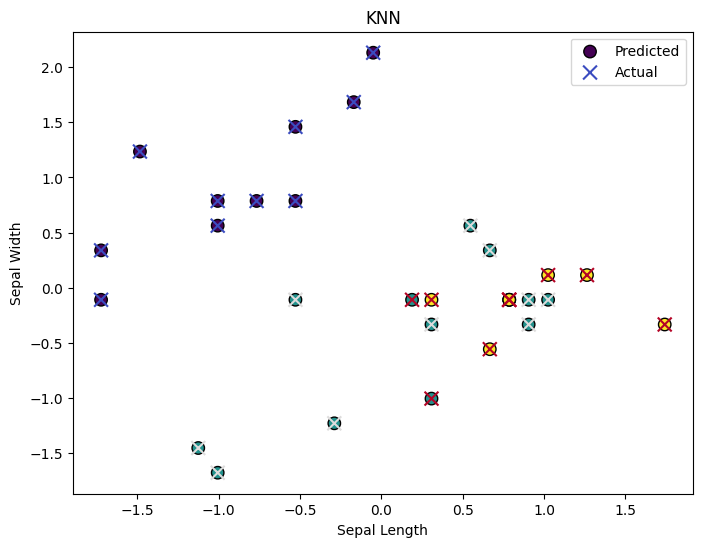

In [59]:
plt.figure(figsize=(8,6))
plt.scatter(x_test[:,0], x_test[:,1], c=y_pred, cmap='viridis',marker='o', edgecolor='k', s=80, label='Predicted')
plt.scatter(x_test[:,0], x_test[:,1], c=y_test, cmap='coolwarm', marker='x', s=100, label='Actual')
plt.title("KNN")
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(['Predicted','Actual'])
plt.show()